In [1]:
import os, sys
import pandas as pd
delphesDir = os.path.abspath("../DelphesLLP")
os.environ['ROOT_INCLUDE_PATH'] = os.path.join(delphesDir,"external")
import ROOT
from helpers import load_lhe_with_corrections, read_root_features, read_lhe_features
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FixedLocator

pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams['figure.max_open_warning'] = 50
plt.rcParams.update({
    
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=2.1)
cm = plt.colormaps['RdYlBu']

colors = sns.color_palette('Paired')


ROOT.gSystem.Load(os.path.join(delphesDir,"libDelphes.so"))

ROOT.gInterpreter.Declare('#include "classes/SortableObject.h"')
ROOT.gInterpreter.Declare('#include "classes/DelphesClasses.h"')
ROOT.gInterpreter.Declare('#include "external/ExRootAnalysis/ExRootTreeReader.h"')



colors = plt.cm.tab10.colors
color_map = {
    'SM': 'gray',
    'VLF': colors[2],
    'Scalar': colors[0],
    'Zprime': colors[3],
    'Zprime_20pc': 'cyan',
    'FakeData': 'black'
}

Welcome to JupyROOT 6.30/06


In [2]:
filesDict = {'Scalar' : {'lhe' :  {'gg' : '../Benchmark_LHEs/Scalar/gg2ttbar/events.lhe.gz',    'qq' : '../Benchmark_LHEs/Scalar/qq2ttbar/events.lhe.gz'},
                      'root' : {'gg' : '../Benchmark_LHEs/Scalar/gg2ttbar/events_delphes.root', 'qq' : '../Benchmark_LHEs/Scalar/qq2ttbar/events_delphes.root'}},
          
          'VLF' :    {'lhe' :  {'gg' : '../Benchmark_LHEs/VLF/gg2ttbar/events.lhe.gz',       'qq' : '../Benchmark_LHEs/VLF/qq2ttbar/events.lhe.gz'},
                      'root' : {'gg' : '../Benchmark_LHEs/VLF/gg2ttbar/events_delphes.root', 'qq' : '../Benchmark_LHEs/VLF/qq2ttbar/events_delphes.root'}},
          'SM' :     {'lhe' :  {'pp' : '../Benchmark_LHEs/SM/pp2ttbar/unweighted_events.lhe.gz'},
                      'root' : {'pp' : '../Benchmark_LHEs/SM/pp2ttbar/unweighted_events_delphes.root'}}}


In [3]:
featuresDict = {}
yDM = {'Scalar' : 7.5, 'VLF' : 3.5, 'SM' : 1.0}
max_events = 300000
for model in filesDict.keys():
    featuresDict[model] = {}
    print('Going over model: ', model)
    if model == 'SM':
        is_nlo = False
    else:
        is_nlo = True
    for filetype in filesDict[model].keys():
        featuresDict[model][filetype] = {}
        for process in filesDict[model][filetype].keys():
            if filetype == 'lhe':
                print('Loading LHE file for process: ', process)
                featuresDict[model][filetype][process] = load_lhe_with_corrections(filesDict[model][filetype][process],
                                                                                   max_events=max_events,is_nlo=is_nlo,
                                                                                   rescale_weight_by=yDM[model]**2)
            elif filetype == 'root':
                print('Loading ROOT file for process: ', process)
                f = ROOT.TFile.Open(filesDict[model][filetype][process])
                rootTree = f.Get("Delphes")
                featuresDict[model][filetype][process] = read_root_features(rootTree,max_events=max_events)
                f.Close()

Going over model:  Scalar
Loading LHE file for process:  gg
Loading None from 1 LHE files...


Reading events.lhe.gz: 0it [00:00, ?it/s]

  -> events.lhe.gz: normalized sum(weights) from -7.945236e-09 to -8.085000e-03 pb
Loading LHE file for process:  qq
Loading None from 1 LHE files...


Reading events.lhe.gz: 0it [00:00, ?it/s]

  -> events.lhe.gz: normalized sum(weights) from 1.781511e-04 to 1.063000e-03 pb
Loading ROOT file for process:  gg
Loading ROOT file for process:  qq
Going over model:  VLF
Loading LHE file for process:  gg
Loading None from 1 LHE files...


...

  -> events.lhe.gz: normalized sum(weights) from 6.325804e-07 to 8.397000e-03 pb
Loading LHE file for process:  qq
Loading None from 1 LHE files...


Reading events.lhe.gz: 0it [00:00, ?it/s]

  -> events.lhe.gz: normalized sum(weights) from 1.120266e-04 to 7.673000e-03 pb
Loading ROOT file for process:  gg
Loading ROOT file for process:  qq
Going over model:  SM
Loading LHE file for process:  pp
Loading None from 1 LHE files...


Reading unweighted_events.lhe.gz: 0it [00:00, ?it/s]

  -> unweighted_events.lhe.gz: normalized sum(weights) from 1.420853e+08 to 4.689400e+02 pb
Loading ROOT file for process:  pp


### Rescale the ROOT cross-sections to match the correc (LHE) values

In [4]:
for model in featuresDict.keys():
    print(f'--- {model} ---')
    for process in featuresDict[model]['lhe'].keys():        
        lhe_xsec = sum(featuresDict[model]['lhe'][process]['weight'])
        root_xsec = sum(featuresDict[model]['root'][process]['weight'])
        factor = lhe_xsec / root_xsec
        featuresDict[model]['root'][process]['weight'] *= factor


--- Scalar ---
--- VLF ---
--- SM ---


In [5]:
for model in featuresDict.keys():
    for filetype in featuresDict[model].keys():
        if 'pp' not in featuresDict[model][filetype].keys():
            featuresDict[model][filetype]['pp'] = pd.concat((featuresDict[model][filetype]['gg'], featuresDict[model][filetype]['qq']), ignore_index=True)

In [6]:
for model in featuresDict.keys():
    print(f'--- {model} ---')
    for process in featuresDict[model]['lhe'].keys():        
        lhe_xsec = sum(featuresDict[model]['lhe'][process]['weight'])
        root_xsec = sum(featuresDict[model]['root'][process]['weight'])*len(featuresDict[model]['lhe'][process])/len(featuresDict[model]['root'][process])
        print(f'{model} ({process}) LHE: {lhe_xsec:1.3e}, ROOT: {root_xsec:1.3e}')


--- Scalar ---
Scalar (gg) LHE: -4.548e-01, ROOT: -4.548e-01
Scalar (qq) LHE: 5.979e-02, ROOT: 5.979e-02
Scalar (pp) LHE: -3.950e-01, ROOT: -3.950e-01
--- VLF ---
VLF (gg) LHE: 1.029e-01, ROOT: 1.029e-01
VLF (qq) LHE: 9.399e-02, ROOT: 9.399e-02
VLF (pp) LHE: 1.969e-01, ROOT: 1.969e-01
--- SM ---
SM (pp) LHE: 4.689e+02, ROOT: 4.689e+02


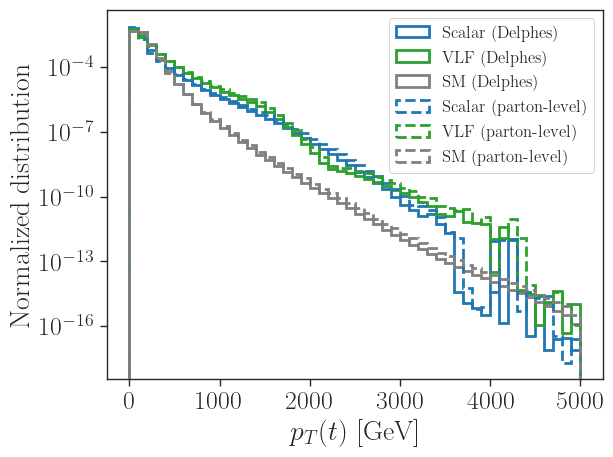

In [7]:
bins = np.arange(0.,5100.,100.)

for model in featuresDict.keys():
    plt.hist(featuresDict[model]['root']['pp']['pt_t'], weights=np.abs(featuresDict[model]['root']['pp']['weight']), 
         bins=bins, density=True, alpha=1.0, label=f'{model} (Delphes)',histtype='step', linewidth=2, color=color_map[model])

for model in featuresDict.keys():
    plt.hist(featuresDict[model]['lhe']['pp']['pt_t'], weights=np.abs(featuresDict[model]['lhe']['pp']['weight']), 
         bins=bins, density=True, alpha=1.0, label=f'{model} (parton-level)',histtype='step', linewidth=2, color=color_map[model], linestyle='--')

plt.legend(fontsize=12)
plt.yscale('log')
plt.xlabel(r'$p_T(t)$ [GeV]')
plt.ylabel(r'Normalized distribution')
plt.show()

In [8]:
mtt_min = 1200.0
print('mtt_min = ', mtt_min)
print('SM:')
sm_pp = featuresDict['SM']['lhe']['pp']
print(sum(sm_pp[sm_pp['m_tt']>mtt_min]['weight']))

print('Scalar:')
scalar_gg = featuresDict['Scalar']['lhe']['gg']
scalar_qq = featuresDict['Scalar']['lhe']['qq']
scalar_pp = featuresDict['Scalar']['lhe']['pp']
print(sum(scalar_qq[scalar_qq['m_tt']>mtt_min]['weight']))
print(sum(scalar_gg[scalar_gg['m_tt']>mtt_min]['weight']))
print(sum(scalar_pp[scalar_pp['m_tt']>mtt_min]['weight']))


print('VLF:')
vlf_gg = featuresDict['VLF']['lhe']['gg']
vlf_qq = featuresDict['VLF']['lhe']['qq']
vlf_pp = featuresDict['VLF']['lhe']['pp']
print(sum(vlf_qq[vlf_qq['m_tt']>mtt_min]['weight']))
print(sum(vlf_gg[vlf_gg['m_tt']>mtt_min]['weight']))
print(sum(vlf_pp[vlf_pp['m_tt']>mtt_min]['weight']))

mtt_min =  1200.0
SM:
4.249827443958082
Scalar:
0.008296937931129908
-0.007623300107136014
0.0006736378239938942
VLF:
0.006498588339752705
0.002552469893378752
0.009051058233131458


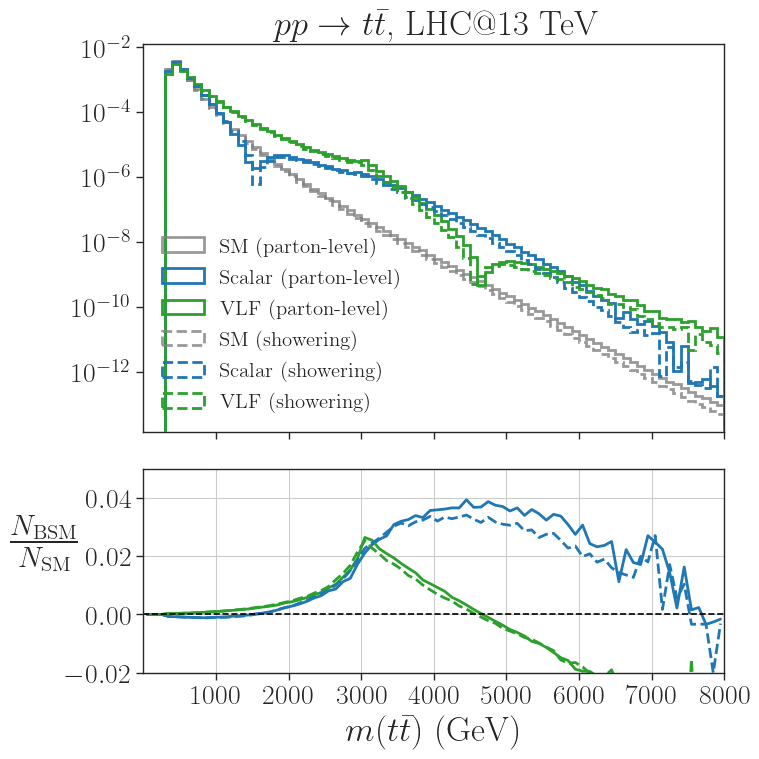

In [11]:
var = 'm_tt'
bins = np.arange(0.,8100.,100.)
x_centers = (bins[:-1] + bins[1:]) / 2.0
fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, hspace=0.1)


lineStyles = {'lhe' : 'solid', 'root' : 'dashed'}
for fileType in  ['lhe', 'root']:
    ls  = lineStyles[fileType]
    h_sm = np.histogram(featuresDict['SM'][fileType]['pp'][var], 
                        bins=bins,weights=featuresDict['SM'][fileType]['pp']['weight'])[0]
    bsm_items = {model : np.histogram(featuresDict[model][fileType]['pp'][var], 
                                      bins=bins,weights=featuresDict[model][fileType]['pp']['weight'])[0] 
                                      for model in featuresDict.keys() if model != 'SM'}


    # 1. Plot SM
    label_str = 'SM'
    if fileType == 'lhe':
        label_str += ' (parton-level)'
    else:
        label_str += ' (showering)'
    axarr[0].hist(bins[:-1], weights=np.abs(h_sm), bins=bins, density=True,
                    color=color_map['SM'], alpha=0.8, histtype='step', 
                    linewidth=2.0, fill=False, zorder=0, label=label_str,linestyle=ls)

    # 2. Plot BSM & Z'
    for model,h_bsm in bsm_items.items():
        display_name = model
        

        if display_name == 'Zprime':
            label_str = r'$Z^\prime$'
        else:
            label_str = rf'{display_name}'
        if fileType == 'lhe':
            label_str += ' (parton-level)'
        else:
            label_str += ' (showering)'

        axarr[0].hist(bins[:-1], weights=np.abs(h_bsm), bins=bins, density=True,
                        color=color_map[display_name], alpha=1.0, histtype='step', 
                        linewidth=2, fill=False, zorder=3, label=label_str,linestyle=ls)

        # 3. Ratio Subplot 
        with np.errstate(divide='ignore', invalid='ignore'):
            raw_ratio = np.nan_to_num(np.array(h_bsm) / h_sm)
            axarr[1].plot(x_centers, raw_ratio, color=color_map[display_name],linewidth=2,linestyle=ls)

axarr[0].set_title(r"$p p \to t \bar{t}$, LHC@13 TeV", fontsize=25)
axarr[0].legend(framealpha=0.0, ncol=1, loc='lower left', fontsize=15)
axarr[0].set_yscale('log')
axarr[0].set_xlim(bins.min(), bins.max())
axarr[0].set_xticks(np.arange(1000.,9000.,1000))
axarr[0].tick_params(axis='both', width=1, labelsize=20)

axarr[1].axhline(y=0, color='k', linestyle='--')
axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$', fontsize=30, rotation=0, labelpad=15) 
axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=25)
axarr[1].set_xticks(np.arange(1000.,9000.,1000))
axarr[1].set_yticks(np.arange(-0.02,0.05,0.02))
axarr[1].set_ylim(-0.02,0.05)
axarr[1].grid(True)
axarr[1].tick_params(axis='both', width=1, labelsize=20)
plt.tight_layout()
plt.savefig('ttbar_mtt_withShowering.pdf', dpi=300, bbox_inches='tight')
plt.show()

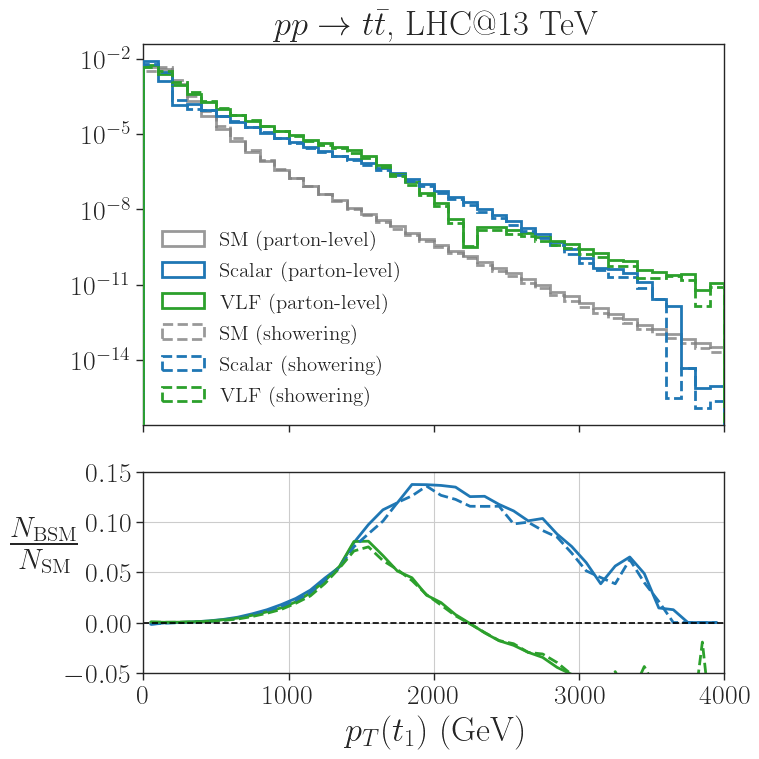

In [16]:
var = 'pt_1'
bins = np.arange(0.,4100.,100.)
x_centers = (bins[:-1] + bins[1:]) / 2.0
fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, hspace=0.1)


lineStyles = {'lhe' : 'solid', 'root' : 'dashed'}
for fileType in  ['lhe', 'root']:
    ls  = lineStyles[fileType]
    h_sm = np.histogram(featuresDict['SM'][fileType]['pp'][var], 
                        bins=bins,weights=featuresDict['SM'][fileType]['pp']['weight'])[0]
    bsm_items = {model : np.histogram(featuresDict[model][fileType]['pp'][var], 
                                      bins=bins,weights=featuresDict[model][fileType]['pp']['weight'])[0] 
                                      for model in featuresDict.keys() if model != 'SM'}


    # 1. Plot SM
    label_str = 'SM'
    if fileType == 'lhe':
        label_str += ' (parton-level)'
    else:
        label_str += ' (showering)'
    axarr[0].hist(bins[:-1], weights=np.abs(h_sm), bins=bins, density=True,
                    color=color_map['SM'], alpha=0.8, histtype='step', 
                    linewidth=2.0, fill=False, zorder=0, label=label_str,linestyle=ls)

    # 2. Plot BSM & Z'
    for model,h_bsm in bsm_items.items():
        display_name = model
        

        if display_name == 'Zprime':
            label_str = r'$Z^\prime$'
        else:
            label_str = rf'{display_name}'
        if fileType == 'lhe':
            label_str += ' (parton-level)'
        else:
            label_str += ' (showering)'

        axarr[0].hist(bins[:-1], weights=np.abs(h_bsm), bins=bins, density=True,
                        color=color_map[display_name], alpha=1.0, histtype='step', 
                        linewidth=2, fill=False, zorder=3, label=label_str,linestyle=ls)

        # 3. Ratio Subplot 
        with np.errstate(divide='ignore', invalid='ignore'):
            raw_ratio = np.nan_to_num(np.array(h_bsm) / h_sm)
            axarr[1].plot(x_centers, raw_ratio, color=color_map[display_name],linewidth=2,linestyle=ls)

axarr[0].set_title(r"$p p \to t \bar{t}$, LHC@13 TeV", fontsize=25)
axarr[0].legend(framealpha=0.0, ncol=1, loc='lower left', fontsize=15)
axarr[0].set_yscale('log')
axarr[0].set_xlim(bins.min(), bins.max())
axarr[0].set_xticks(np.arange(0.,4100.,1000))
axarr[0].tick_params(axis='both', width=1, labelsize=20)

axarr[1].axhline(y=0, color='k', linestyle='--')
axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$', fontsize=30, rotation=0, labelpad=15) 
axarr[1].set_xlabel(r'$p_T(t_1)$ (GeV)', fontsize=25)
axarr[1].set_xticks(np.arange(0.,4100.,1000))
axarr[1].set_yticks(np.arange(-0.05,0.20,0.05))
axarr[1].set_ylim(-0.05,0.15)
axarr[1].grid(True)
axarr[1].tick_params(axis='both', width=1, labelsize=20)
plt.tight_layout()
plt.savefig('ttbar_pt1_withShowering.pdf', dpi=300, bbox_inches='tight')
plt.show()

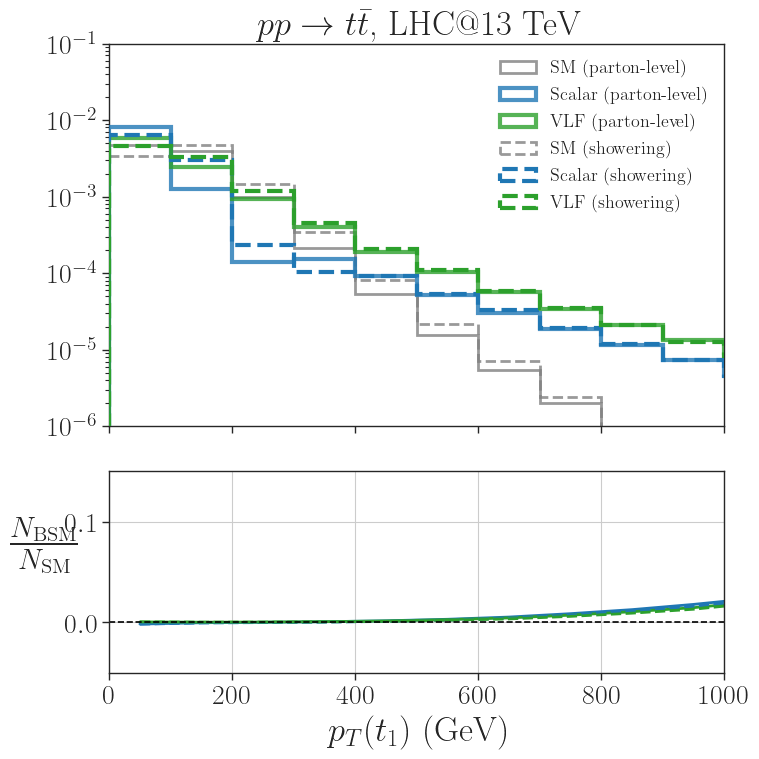

In [23]:
var = 'pt_1'
bins = np.arange(0.,4100.,100.)
x_centers = (bins[:-1] + bins[1:]) / 2.0
fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, hspace=0.1)


lineStyles = {'lhe' : 'solid', 'root' : 'dashed'}
for fileType in  ['lhe', 'root']:
    ls  = lineStyles[fileType]
    h_sm = np.histogram(featuresDict['SM'][fileType]['pp'][var], 
                        bins=bins,weights=featuresDict['SM'][fileType]['pp']['weight'])[0]
    bsm_items = {model : np.histogram(featuresDict[model][fileType]['pp'][var], 
                                      bins=bins,weights=featuresDict[model][fileType]['pp']['weight'])[0] 
                                      for model in featuresDict.keys() if model != 'SM'}


    # 1. Plot SM
    label_str = 'SM'
    if fileType == 'lhe':
        label_str += ' (parton-level)'
    else:
        label_str += ' (showering)'
    axarr[0].hist(bins[:-1], weights=np.abs(h_sm), bins=bins, density=True,
                    color=color_map['SM'], alpha=0.8, histtype='step', 
                    linewidth=2.0, fill=False, zorder=0, label=label_str,linestyle=ls)

    # 2. Plot BSM & Z'
    for model,h_bsm in bsm_items.items():
        display_name = model
        

        if display_name == 'Zprime':
            label_str = r'$Z^\prime$'
        else:
            label_str = rf'{display_name}'
        if fileType == 'lhe':
            label_str += ' (parton-level)'
            alpha = 0.8
        else:
            label_str += ' (showering)'
            alpha = 1.0

        axarr[0].hist(bins[:-1], weights=np.abs(h_bsm), bins=bins, density=True,alpha=alpha,
                        color=color_map[display_name], histtype='step', 
                        linewidth=3, fill=False, zorder=3, label=label_str,linestyle=ls)

        # 3. Ratio Subplot 
        with np.errstate(divide='ignore', invalid='ignore'):
            raw_ratio = np.nan_to_num(np.array(h_bsm) / h_sm)
            axarr[1].plot(x_centers, raw_ratio, color=color_map[display_name],linewidth=2,linestyle=ls)

axarr[0].set_title(r"$p p \to t \bar{t}$, LHC@13 TeV", fontsize=25)
axarr[0].legend(framealpha=0.0, ncol=1, loc='upper right', fontsize=13)
axarr[0].set_yscale('log')
axarr[0].set_xlim(bins.min(), 1000.0)
axarr[0].set_ylim(1e-6, 1e-1)
# axarr[0].set_xticks(np.arange(0.,4100.,1000))
axarr[0].tick_params(axis='both', width=1, labelsize=20)

axarr[1].axhline(y=0, color='k', linestyle='--')
axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$', fontsize=30, rotation=0, labelpad=15) 
axarr[1].set_xlabel(r'$p_T(t_1)$ (GeV)', fontsize=25)
# axarr[1].set_xticks(np.arange(0.,4100.,1000))
# axarr[1].set_yticks(np.arange(-0.05,0.20,0.05))
axarr[1].set_ylim(-0.05,0.15)
axarr[1].grid(True)
axarr[1].tick_params(axis='both', width=1, labelsize=20)
# plt.savefig('ttbar_pt1_withShowering.pdf', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()